<a href="https://colab.research.google.com/github/maheck9/SynapseLP/blob/week4/Mahek_Synapse_LP_Task_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Task 4**

## **DJS Synapse Learning Period**
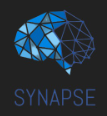

Congratulations on making it this far!! Welcome to the world of classification where we move on from unsupervised to helping the algorithms by telling them exactly what the data we're feeding them is. This week we'll be looking into  many algorithms such as Decision Trees, SVC, Naive Bayes, Random Forest and so on. We'll also be delving into hyperparameter tuning the only place where ched chaad can lead to a good result.

**Warning: This task contains many theory questions. Proceed with caution!**

Jk, make sure you research well and make sure you are understanding the models y'all are implementing as that will make your concepts much stronger and build a strong ML foundation which will be very useful as we move further with the tasks.

### Overfitting and Underfitting [VERY IMPORTANT]:
https://www.youtube.com/watch?v=T9NtOa-IITo
Note : This concept can be seen in K Means and decision trees. In fact, we will look deeper into
this when we begin deep learning.

## Importing the dataset

Use this link to download the adult income dataset and upload it to your drive.

https://drive.google.com/file/d/1VAE1qF16D-sKnBOWXzGXVNGhtNZNLFQS/view?usp=sharing

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import matplotlib.pyplot as plt

Mounted at /content/drive


In [3]:
#import your dataset here
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/adult_income_dataset.csv")
df.head(10)



,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


## Dealing with Nan values

In [4]:
#write a code to find the nan values for the dataset and make a decision on whether to dropna or fill na
df.isna().sum()
#has 32k rows

,0
age,0
workclass,1836
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,1843
relationship,0
race,0
sex,0


In [5]:
df.shape


(32561, 15)

In [6]:
# drop = too many values you don't know the answers to
# fill = when it's very important, only a few values are missing, you can correctly predict the missing values

# fill because very few missing values and it's important for analysis
df['workclass'] = df['workclass'].fillna(df['workclass'].mode()[0])
df['occupation'] = df['occupation'].fillna(df['occupation'].mode()[0])

# drop native-country because it's not that critical
df = df.dropna(subset=['native-country'])


In [7]:
df.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


## Object Valued Columns

For Relationship, Race and Sex find out the max division average fnlwgt for each unique value.

In [8]:
#fnlwgt means final weight = It’s a number that tells you how many people in the population a single row in your dataset represents.
#So, a higher average fnlwgt for a group means that group represents more people in the population.

#group data into categories->find avg fnlwgt->find which group has max

avg_fnlwgt_relationship = df.groupby('relationship')['fnlwgt'].mean()
display(avg_fnlwgt_relationship)

avg_fnlwgt_race = df.groupby('race')['fnlwgt'].mean()
display(avg_fnlwgt_race)

avg_fnlwgt_sex = df.groupby('sex')['fnlwgt'].mean()
display(avg_fnlwgt_sex)

,fnlwgt
relationship,
Husband,186782.867846
Not-in-family,191199.931707
Other-relative,204891.394958
Own-child,193292.562637
Unmarried,191235.404551
Wife,182104.330508


,fnlwgt
race,
Amer-Indian-Eskimo,120831.147910
Asian-Pac-Islander,158664.235356
Black,228467.466314
Other,197205.897233
White,187230.218483


,fnlwgt
sex,
Female,185869.007730
Male,191622.860786


## Getting rid of unnecessary columns

*   Drop the education num column since we already have their education in the form of categories
*   Check the combinations of the marital-status and relationship column, see if we need both of them or just marital status will work too.


In [9]:
#write your code here
df = df.drop('education-num', axis=1) #axis=0 means drop rows and axis = 1 means drop columns
df = df.drop('native-country',axis = 1)

In [10]:
combinations = df.groupby(['marital-status', 'relationship']).size().reset_index(name='count')
display(combinations)
#i doubt we need them both so i think drop marital status
df=df.drop('marital-status',axis=1)

,marital-status,relationship,count
0,Divorced,Not-in-family,2381
1,Divorced,Other-relative,108
2,Divorced,Own-child,326
3,Divorced,Unmarried,1579
4,Married-AF-spouse,Husband,9
5,Married-AF-spouse,Other-relative,1
6,Married-AF-spouse,Own-child,1
7,Married-AF-spouse,Wife,12
8,Married-civ-spouse,Husband,12938
9,Married-civ-spouse,Not-in-family,17


## Dealing with Categorical Data
As you probably know by now, the ML models dont know how to deal with String or object type data... so your mission shall you choose to accept it (don't really have much of a choice) is to find out which columns to do one hot encoding on and which columns to do Label Encoding on.

**Hint: Since Marital-status has less number of columns (distinct values na), One Hot encode it**

One hot encoding : while label encoding gives numbers it might seem like its giving precedence to them which isn't true so instead we make seperate columns for each option
Label encoding : multiple categories so you basically give them numbers

In [11]:
df.head(5)

,age,workclass,fnlwgt,education,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,income
0,39,State-gov,77516,Bachelors,Adm-clerical,Not-in-family,White,Male,2174,0,40,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,Exec-managerial,Husband,White,Male,0,0,13,<=50K
2,38,Private,215646,HS-grad,Handlers-cleaners,Not-in-family,White,Male,0,0,40,<=50K
3,53,Private,234721,11th,Handlers-cleaners,Husband,Black,Male,0,0,40,<=50K
4,28,Private,338409,Bachelors,Prof-specialty,Wife,Black,Female,0,0,40,<=50K


In [12]:
#Write your code here
#Hint: Check which needs one hot encoding which needs label encoding
#Then perform necessary transformations (Feel free to add more coding cells)

#acc to me one hot encode all cause svm and stuff might get affected by giving precedence to stuff which is basically label encoding

categorical_cols = ['workclass', 'education', 'occupation', 'relationship', 'race', 'sex']

# One-hot encode and update your DataFrame
# This will add new columns for each category and remove the originals
df = pd.get_dummies(df, columns=categorical_cols)


In [13]:
df.head(5)

,age,fnlwgt,capital-gain,capital-loss,hours-per-week,income,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,workclass_Private,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Amer-Indian-Eskimo,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Female,sex_Male
0,39,77516,2174,0,40,<=50K,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
1,50,83311,0,0,13,<=50K,False,False,False,False,...,False,False,False,False,False,False,False,True,False,True
2,38,215646,0,0,40,<=50K,False,False,False,True,...,False,False,False,False,False,False,False,True,False,True
3,53,234721,0,0,40,<=50K,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True
4,28,338409,0,0,40,<=50K,False,False,False,True,...,False,False,True,False,False,True,False,False,True,False


## Altering the Target Column
Modify the Target Column (income) to make sure that all the values which are <=50K are replaced with a 0 and the values >50K are replaced with a 1.

In [14]:
#write your code here
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})
#remember map - basically means to use that particular function every value of the list or loop

**Extract the target column(income) and store it in a seperate variable and remove it from the original dataset. Additionally, do a 70:30 Train Test Split**

In [15]:
#write your code here
y = df['income'] #my target - shit i need to find

df.drop('income',axis=1,inplace=True)





In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.3, random_state=42)


### Chalo now that we have the preprocessed data we can feed it into the models. Lets start with some basic ones.

# Logistic Regression
*   Theory:https://www.youtube.com/watch?v=yIYKR4sgzI8&list=PLblh5JKOoLUKxzEP5HA2d-Li7IJkHfXSe
*   Implementation: https://www.youtube.com/watch?v=n40hS9tQmcY


Explain the algorithm, its working and its use cases.

Logistic is unlike linear regression which finds a bestfit line to predict numerical data , logistic finds the best fit s shaped curve to find whether the probability of an event happening is either True(1) or false (0)

We use maximum likelihood method to find the best fit curve basically we make a curve and then search for its probab if producing the actual labels like obese or not obese

eg)if we get a mouse the model will tell us its probab of being obese and then we use classification to see if >50% then obese otherwise not

In [17]:
#import the model and apply it to the data
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler #used for standardization
#scaling is necessary otherwise too many iterations and too much time
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter = 4000)

model.fit(X_train_scaled,y_train)

y_pred = model.predict(X_test_scaled)


Find the accuracy and confusion matrix for the same and explain what it shows.

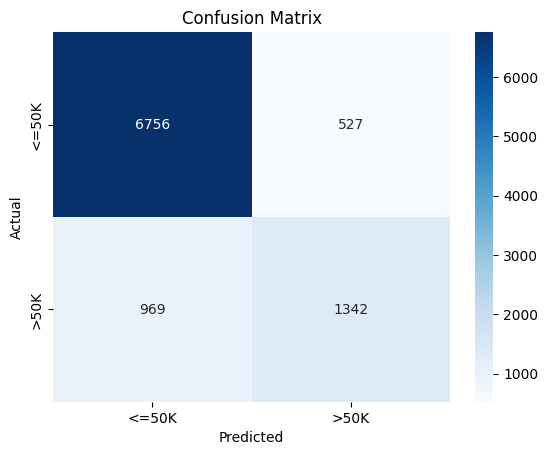

Accuracy: 0.8440692099228685
              precision    recall  f1-score   support

           0       0.87      0.93      0.90      7283
           1       0.72      0.58      0.64      2311

    accuracy                           0.84      9594
   macro avg       0.80      0.75      0.77      9594
weighted avg       0.84      0.84      0.84      9594



In [18]:
import seaborn as sns
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))


### Now that you have printed a confusion matrix and classification report. Let's see what you have understood from it. Write a short paragraph highlighting what you understoood from it below.

confusion matrix is basically how confused your model really is:
show the google doc  


# Naive Bayes Algorithm

* Theory : https://youtu.be/jS1CKhALUBQ
* Theory:
https://www.analyticsvidhya.com/blog/2021/09/naive-bayes-algorithm-a-complete-guide-for-data-science-enthusiasts/
* Implementation : https://youtu.be/nHIUYwN-5rM

In [19]:
#import the model from sklearn and apply it to your data
from sklearn.naive_bayes import GaussianNB
# Make predictions
model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of Naive Bayes:",accuracy ,"%")


#---!!!!i dont really get the implementation video ask!!!---

Accuracy of Naive Bayes: 0.7915363769022306 %


# Decision Tree Classifier
* Theory : https://youtu.be/7VeUPuFGJHk
* Theory: https://www.analyticsvidhya.com/blog/2021/08/decision-tree-algorithm/
* Implementation : https://youtu.be/HY2DcBhgwm0

In [1]:
#import the decision tree from sklearn and run it on your data


<b>Print the Model Accuracy</b>

## Explain: What are the differences in the working of Logistic Regression, Naive Bayes and Decision Tree and explain why are the accuracies are different.

Ans:

### Mention some real life use cases for each of these three models:

Ans:

Now that you have your first result, make sure that you play with the hyperparameters to get a better result. Visualize results, try different hyperparameters by using a loop, GET CREATIVE!<br>

Machine learning is an iteritive process. You will have to keep playing with hyperparameters and algorithms. No fixed algorithm will work on a fixed dataset.

Take this up as a challenge. The person with the best accuracy wins the round!

In [20]:
#plot a graph that shows the train and test accuracy for increasing depth of the tree (do for 10)


In [21]:
#complete the code below to create an image of the decision tree
from sklearn import tree
!pip install graphviz
decision_tree = tree.export_graphviz #(ur model name, out_file='tree.dot', feature_names=X_train.columns, max_depth=2, filled=True)
!dot -Tpng tree.dot -o tree.png # to convert the file
image = plt.imread('tree.png')
plt.figure(figsize=(15,15))
plt.imshow(image)

Error: dot: can't open tree.dot


FileNotFoundError: [Errno 2] No such file or directory: 'tree.png'

<b>print the test accuracy and train accuracy here</b>

In [ ]:
#write code here


### Explain the different hyperparameters you changed and how did it affect the models. Also give a summary of the graphs you made.

Ans:

## SUPPORT VECTOR MACHINE (SVM)

Theory : https://www.youtube.com/watch?v=efR1C6CvhmE (Part 1)

Theory: https://www.youtube.com/watch?v=H9yACitf-KM

Maths Intuition : https://www.youtube.com/watch?v=Js3GLb1xPhc

EXTRAS:

https://www.youtube.com/watch?v=NDqACjz5j8g

If you are more curious and want to explore :

https://www.youtube.com/watch?v=Toet3EiSFcM (Part 2)

https://www.youtube.com/watch?v=efR1C6CvhmE&t=432s (Part 3)

https://www.youtube.com/watch?v=8bFKyb77vp0




In [ ]:
#Now that we know SVM is sensitive to feature scales, so standardize (don't forget to standardise your X_test):


In [ ]:
#Train your model


In [ ]:
#Predict and check accuracies


In [ ]:
#let's try out using different kernels now. Freedom to choose lies in your hands. EXPLOREEE!


## BIAS AND VARIANCE
### Hurrayy! You have made it so far sane.

### Before moving forward let's first understand what exactly do you mean by bias and variance.

THEORY: https://www.geeksforgeeks.org/machine-learning/bias-vs-variance-in-machine-learning/ (explained in quite detail do read this not just video)

VIDEO: https://www.youtube.com/watch?v=EuBBz3bI-aA


## Optimizing Methods

We can even use Ensemble Methods like **bagging (random forest)**, **boosting (adaboost)** and **Pruning** to improve your accuracy. Again creating a loop of hyperparameters and then finding the best among them is a daunting task. To reduce the efforts, we can use a special technique known as **GridSearchCV**. It finds the best hyperparameters for your model without you having to write multiple loops and evaluating them.

1. GridSearchCV for Random Forest Classifier: https://youtu.be/c4mS7KaOIGY
2. GridSearchCV for Adaboost Classifier: https://youtu.be/JmXnztjULnQ

### 1. Bagging

* Theory : https://www.youtube.com/watch?v=KIOeZ5cFZ50
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
* Implementation : https://www.youtube.com/watch?v=MxiktOPmhV8&t=2s

In [ ]:
#implement Random forest
from sklearn.ensemble import RandomForestClassifier

# Initialize the RandomForestClassifier


# Train the model


# Make predictions on the test data

# Evaluate the model's performance


# Optional: Generate a classification report for more details


In [ ]:
#find the accuracy


### Explain the difference between random forest and decision tree. Also think of cases where the outputs for both of them can be same if its possible.

Ans :

In [ ]:
#write a code to implement BaggingClassifier


# Initialize the base estimator (e.g., Decision Tree)

# Initialize the BaggingClassifier


# Train the Bagging model

# Make predictions on the test data

# Evaluate the model's performance


# Optional: Generate a classification report for more details


### Explain how are Bagging and Random Forest different and why do we do bagging?


Ans :

### 2. Boosting

* Theory : https://www.youtube.com/watch?v=NLRO1-jp5F8&t=724s
* Theory :
https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html
*   Theory:https://www.geeksforgeeks.org/ml-xgboost-extreme-gradient-boosting/
* Implementation : https://www.youtube.com/watch?v=7xHM93WXOu8

In [ ]:
#write code here

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import cross_val_score

#yk the drill now


Just to make things more interesting implement XGBoost as well and compare its accuracy with that of AdaBoost :)

In [ ]:
!pip install xgboost
import xgboost as xgb


### Explain: What is the difference between Adaboost and XGBoost. Also describe in what cases is XGBoost better to use than AdaBoost.

Ans :

## Explain: What is the difference between Bagging and Boosting? Explain with examples

Ans:








### 3. Pruning Techniques



*   Theory: https://opendatascience.com/what-is-pruning-in-machine-learning/
*   Theory:https://towardsdatascience.com/build-better-decision-trees-with-pruning-8f467e73b107



In [ ]:
#implement pruning


In [ ]:
#before plotting a tree you will need to first convert your X_train and X_test to DataFrame (Explain WHY (Hint: You made one tree before and it worked fine so it has to do with something you did after..Explore))
#Code to convert it here:




In [ ]:
#plot a tree (image) similar to one created for decision tree (graphwiz) for the pruning technique


<b>Note that the accuracy on the test set will be considered and brownie points for *not* overfitting the model in the process</b>

As a brush up on data visualisation... make a graph to compare the accuracies you achieved for each of the models you trained and explain which one is the best to perform classification tasks and why?

In [ ]:
#write your code here


# **RESEARCH TASK**

Ensemble Models are not only used for classification but also for Regression.Research on the various regression models such as XGBoost Regressor and Random Forest regressor and how are they different from the Linear Regression model we made in Task 2. The best research will be edited and featured on the Synapse Instagram page. Happy coding! :)

# **End of Task**

> ©DJS Synapse 2025 - 2026